# Day 08. Exercise 05
# Clustering

## 0. Imports

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np 

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [62]:
df = pd.read_csv("../data/regression.csv")

In [63]:
df = df.drop('pageviews', axis=1)
df

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
5,user_19,118,-98.750000
6,user_21,65,-95.500000
7,user_25,79,-92.600000
8,user_28,60,-86.400000
9,user_3,18,-105.400000


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [41]:
features = df[["num_commits", "AVG(diff)"]]

kmeans = KMeans(n_clusters=3, random_state=21)
kmeans.fit(features)

labels = kmeans.labels_
labels

array([1, 0, 2, 0, 0, 1, 1, 1, 1, 2, 2, 0, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0,
       0, 2, 1, 2, 0, 2, 2], dtype=int32)

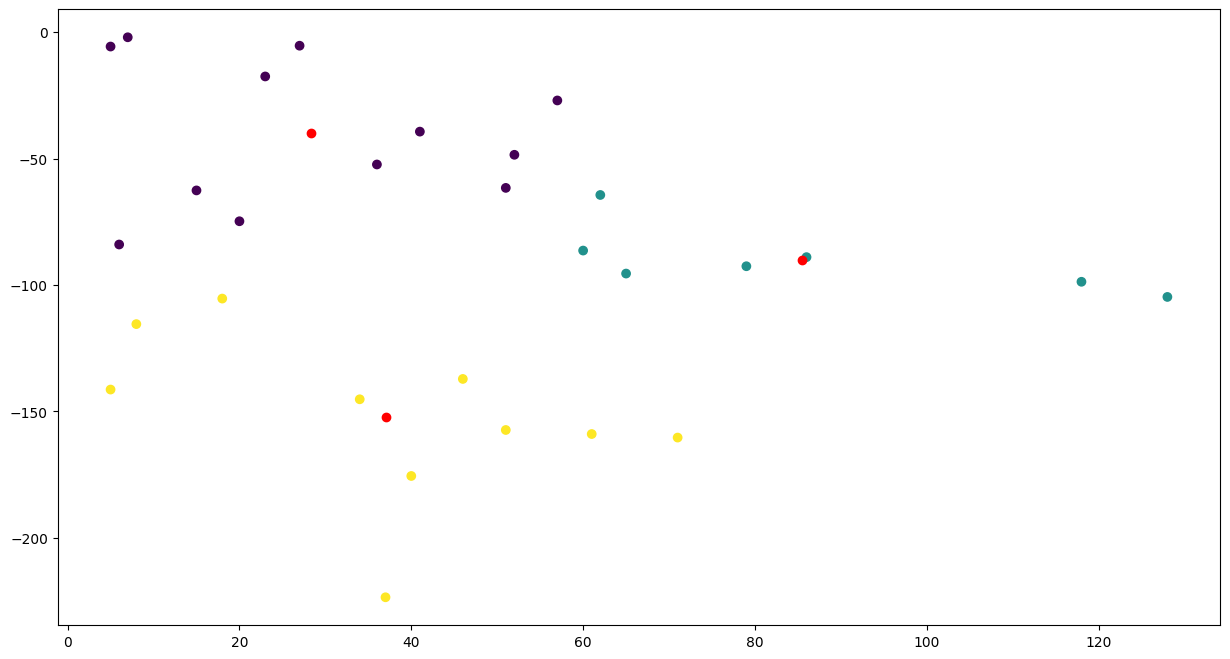

In [33]:
plt.figure(figsize=(15, 8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red')
plt.show()

In [42]:
silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.4390170957153295

In [39]:
features = df[["num_commits", "AVG(diff)"]]

kmeans = KMeans(n_clusters=5, random_state=21)
kmeans.fit(features)

labels = kmeans.labels_
labels

array([0, 0, 2, 0, 3, 1, 1, 1, 1, 4, 2, 3, 1, 0, 3, 0, 2, 0, 4, 4, 2, 0,
       3, 2, 1, 2, 0, 4, 2], dtype=int32)

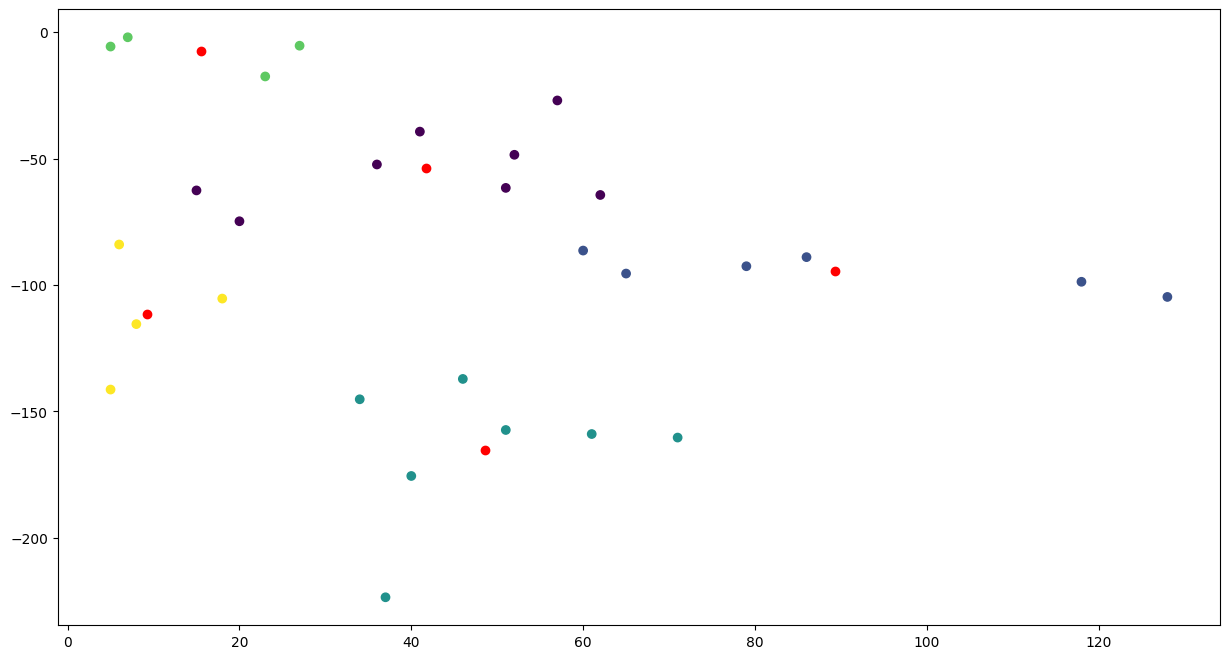

In [31]:
plt.figure(figsize=(15, 8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red')
plt.show()

In [35]:
features = df[["num_commits", "AVG(diff)"]]

kmeans = KMeans(n_clusters=2, random_state=21)
kmeans.fit(features)

labels = kmeans.labels_
labels

array([0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1], dtype=int32)

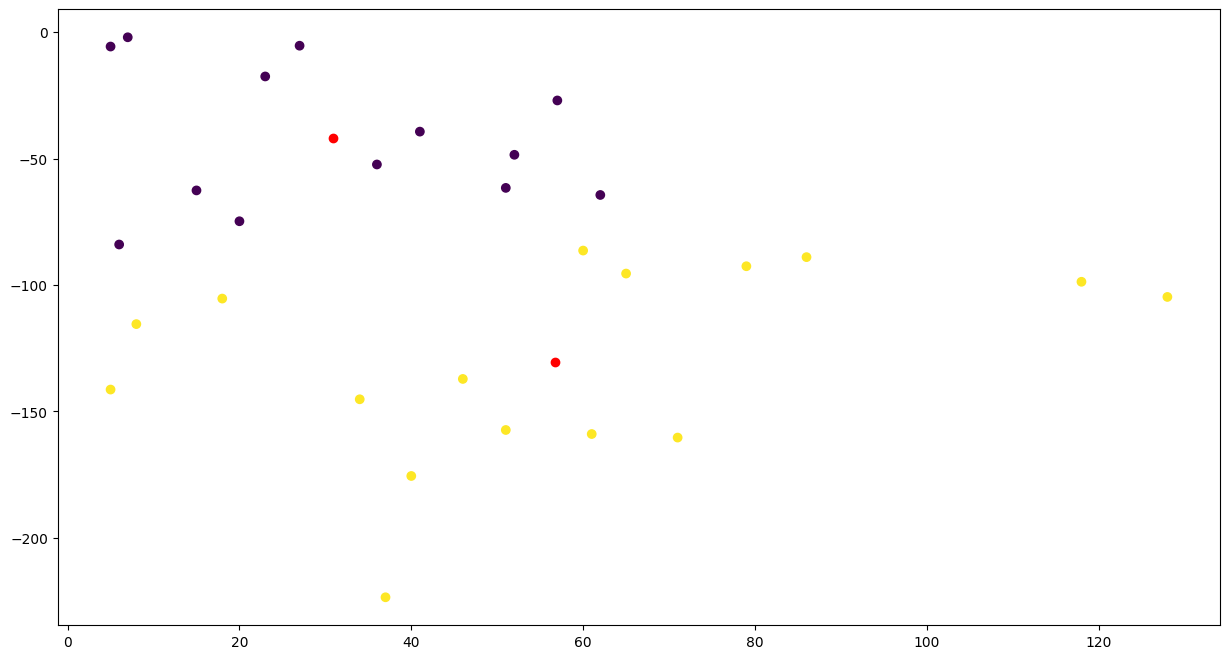

In [36]:
plt.figure(figsize=(15, 8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red')
plt.show()

In [58]:
features = df[["num_commits", "AVG(diff)"]]

kmeans = KMeans(n_clusters=8, random_state=21)
kmeans.fit(features)

labels = kmeans.labels_
labels

array([5, 1, 0, 5, 3, 2, 7, 7, 7, 4, 0, 3, 7, 5, 3, 5, 0, 5, 4, 1, 6, 5,
       3, 0, 2, 0, 1, 4, 0], dtype=int32)

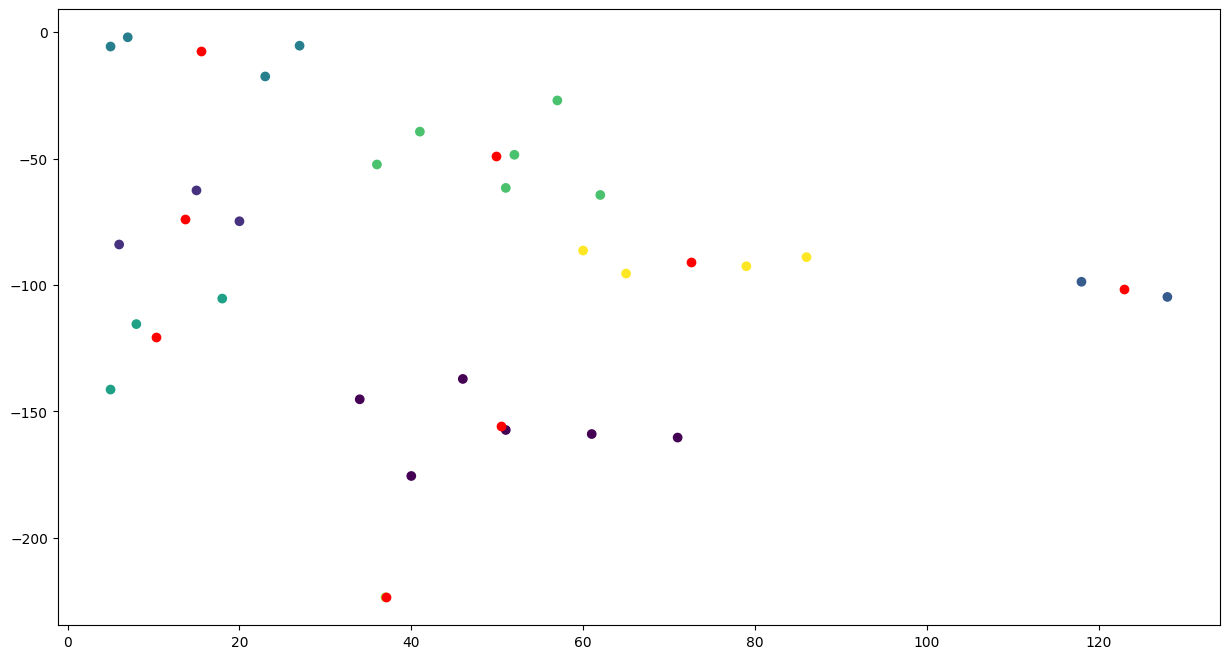

In [59]:
plt.figure(figsize=(15, 8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red')
plt.show()

In [60]:
silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.5077985556562201

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [66]:
dbscan = DBSCAN(eps=20, min_samples=2)
dbscan.fit(features)

labels = dbscan.labels_
labels

array([ 0,  1,  2,  0,  3,  4,  5,  5,  5,  6,  7,  3,  5,  0,  8,  0,  7,
       -1, -1,  1, -1,  0,  8,  2,  4, -1,  1,  6,  2])

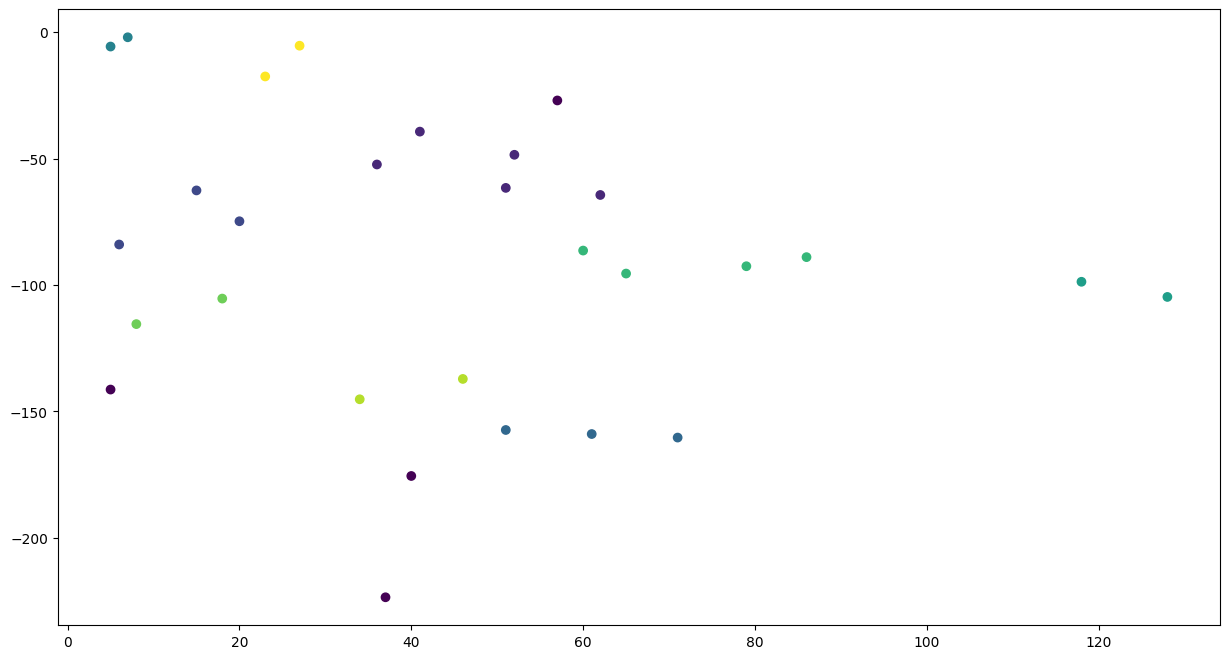

In [67]:
plt.figure(figsize=(15,8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.show()

In [69]:
silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.38339641455696616

In [101]:
dbscan = DBSCAN(eps=36, min_samples=6)
dbscan.fit(features)

labels = dbscan.labels_

silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.35170090624559835

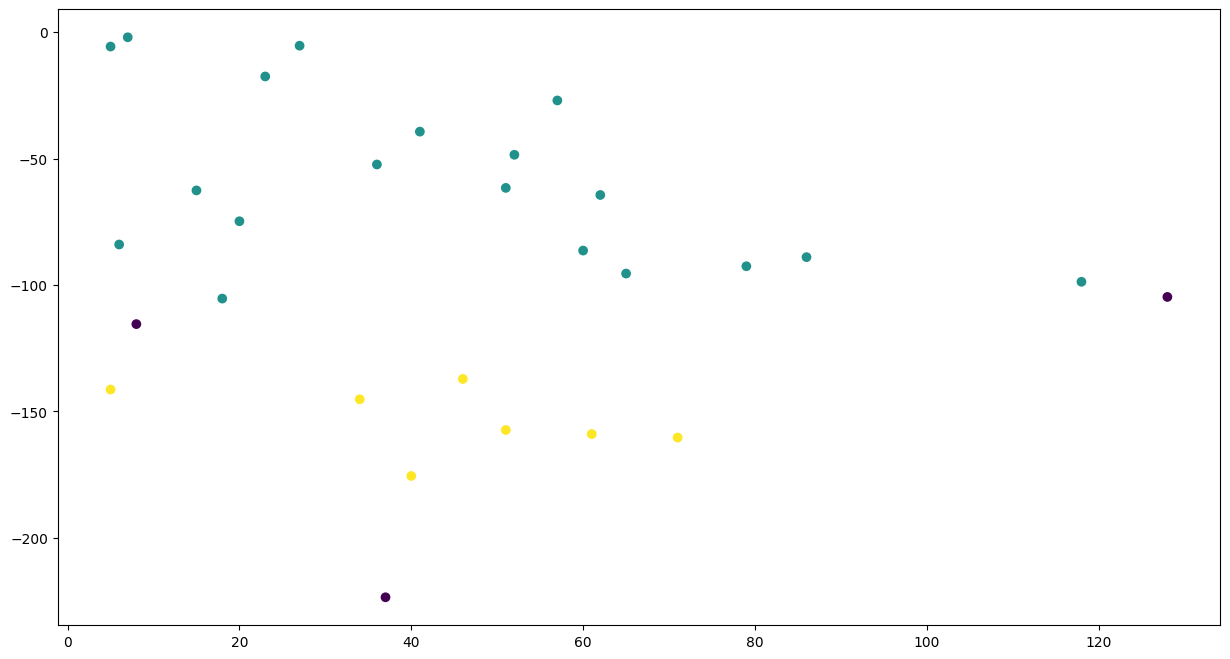

In [102]:
plt.figure(figsize=(15,8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.show()

In [105]:
dbscan = DBSCAN(eps=22, min_samples=1)
dbscan.fit(features)

labels = dbscan.labels_

silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.48713041554757475

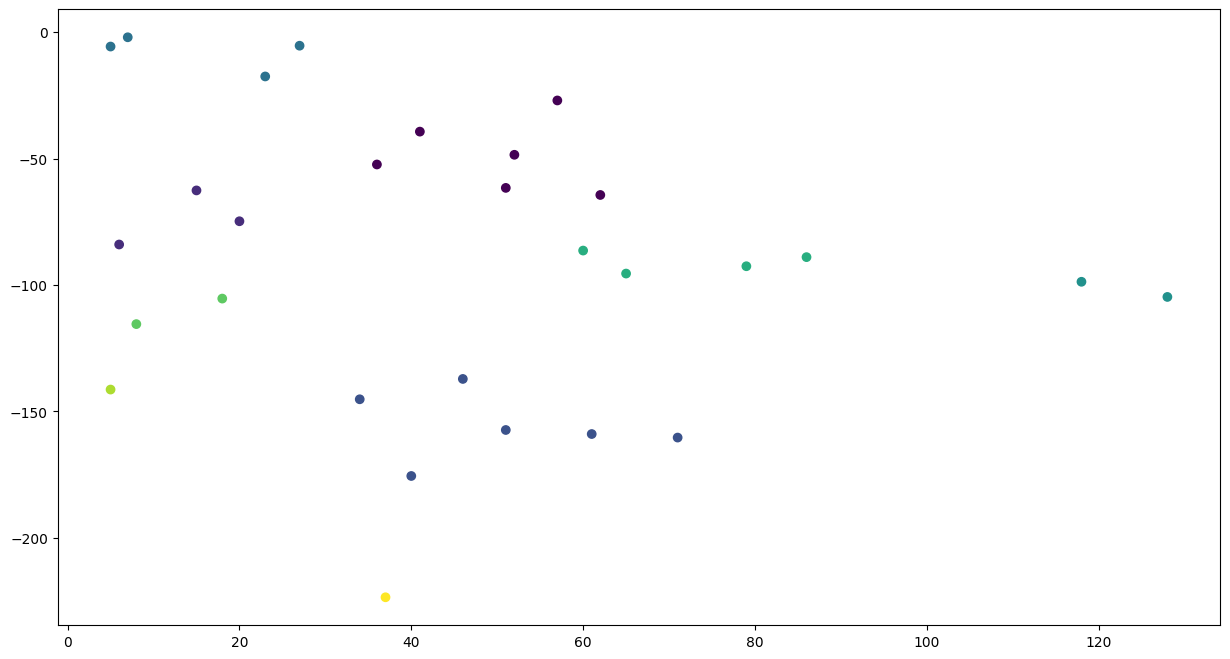

In [106]:
plt.figure(figsize=(15,8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [110]:
hierarchical = AgglomerativeClustering(n_clusters=5)
hierarchical.fit(features)

labels = hierarchical.labels_
labels


array([2, 3, 0, 2, 4, 1, 1, 1, 1, 3, 0, 4, 1, 2, 4, 2, 0, 2, 3, 3, 0, 2,
       4, 0, 1, 0, 3, 3, 0])

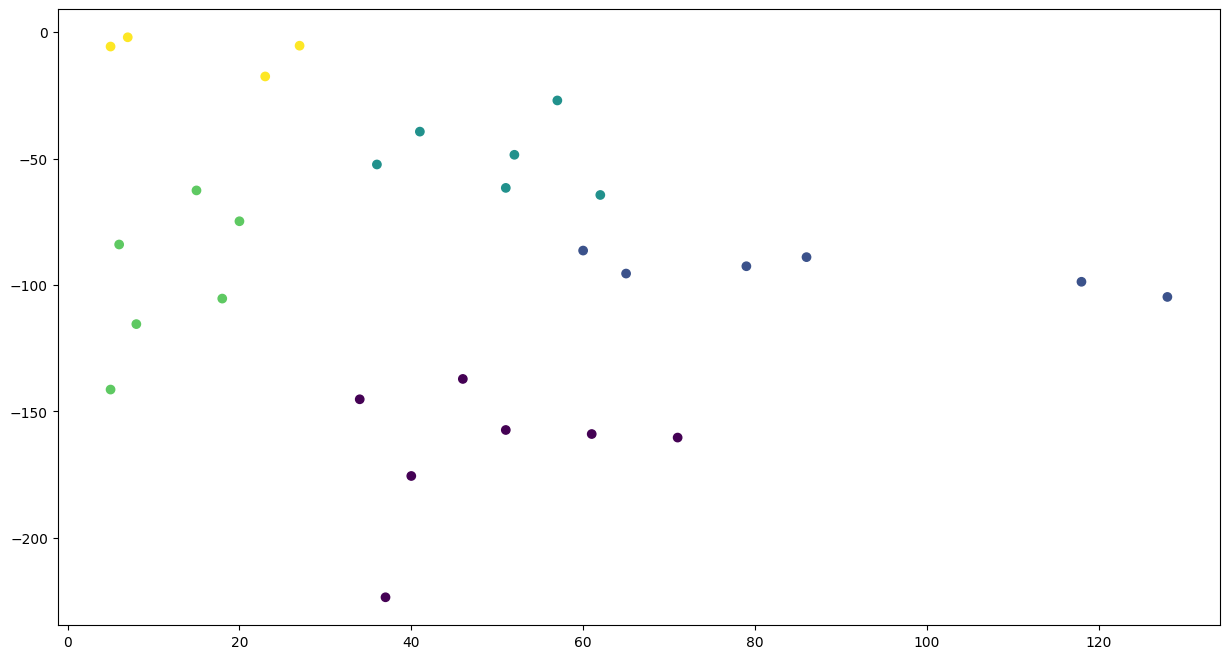

In [111]:
plt.figure(figsize=(15, 8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.show()

In [112]:
silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.46383015199381467

In [146]:
hierarchical = AgglomerativeClustering(n_clusters=8)
hierarchical.fit(features)

labels = hierarchical.labels_
silhoettte_avg = silhouette_score(features, labels)
silhoettte_avg

0.5077985556562201

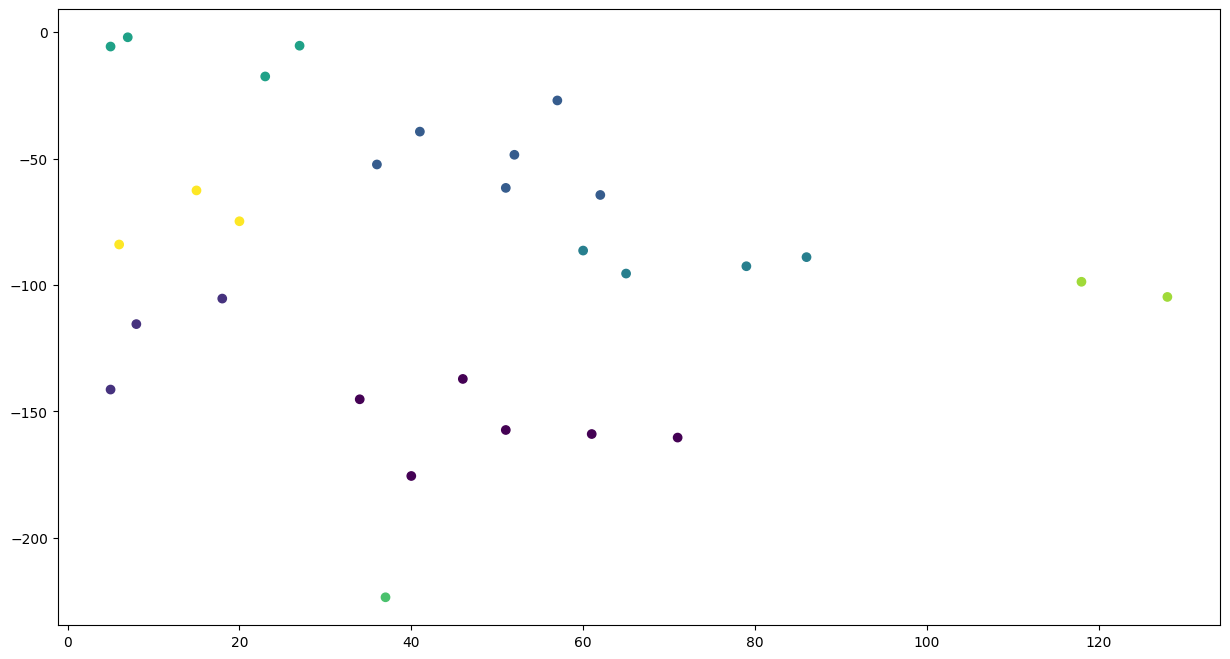

In [127]:
plt.figure(figsize=(15, 8))
plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
plt.show()

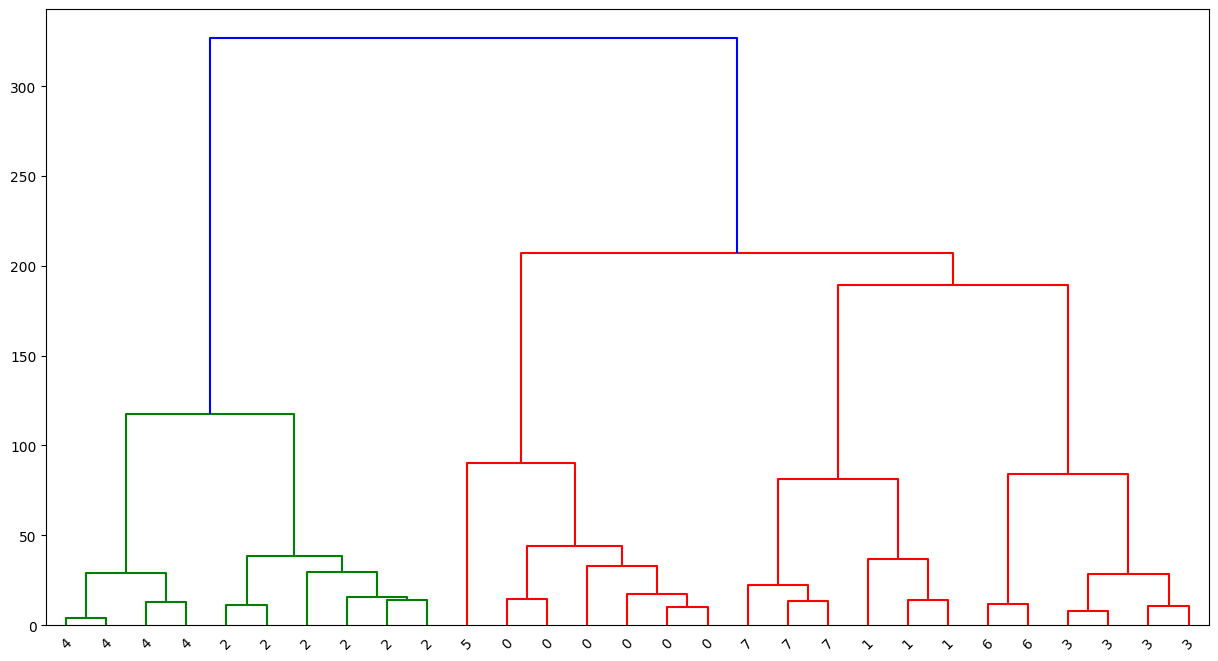

In [147]:
Z = linkage(features, method='ward')
plt.figure(figsize=(15,8))
dendrogram(Z=Z, labels=labels.tolist())
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

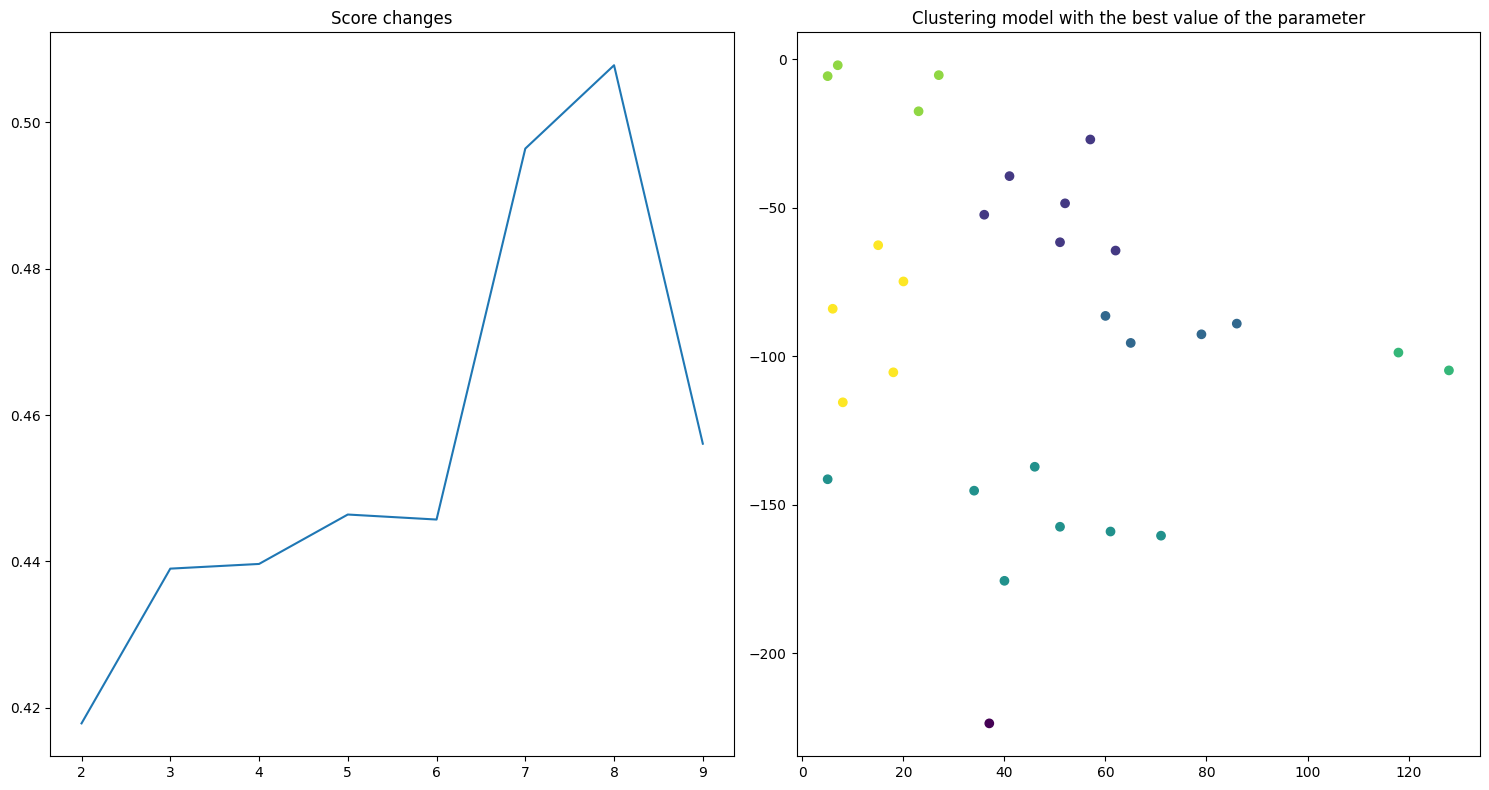

In [173]:
def func(type_of_model, features, param_name, param_range, **model_param):
    pairs = {}
    for num in param_range:
        param = {param_name: num}
        model = type_of_model(**model_param, **param)

        model.fit(features)
        labels = model.labels_

        silhoettte_avg = silhouette_score(features, labels)
        pairs[num] = silhoettte_avg 

    values = list(pairs.keys())
    scores = list(pairs.values())
    plt.figure(figsize=(15, 8))
    plt.subplot(1,2,1)
    plt.plot(values, scores)
    plt.title('Score changes')
    

    max_score = -1
    for num, score in enumerate(pairs):
        if score >= max_score:
            max_score = score
            best_num = int(num)

    best_param = {param_name: best_num}
    best_model = type_of_model(**model_param, **best_param)
    best_model.fit(features)
    labels = best_model.labels_

    plt.subplot(1,2,2)
    plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
    plt.title('Clustering model with the best value of the parameter')
    plt.tight_layout()
    plt.show()

func(type_of_model=KMeans, features=features, param_name="n_clusters", param_range=range(2,10), random_state = 21)

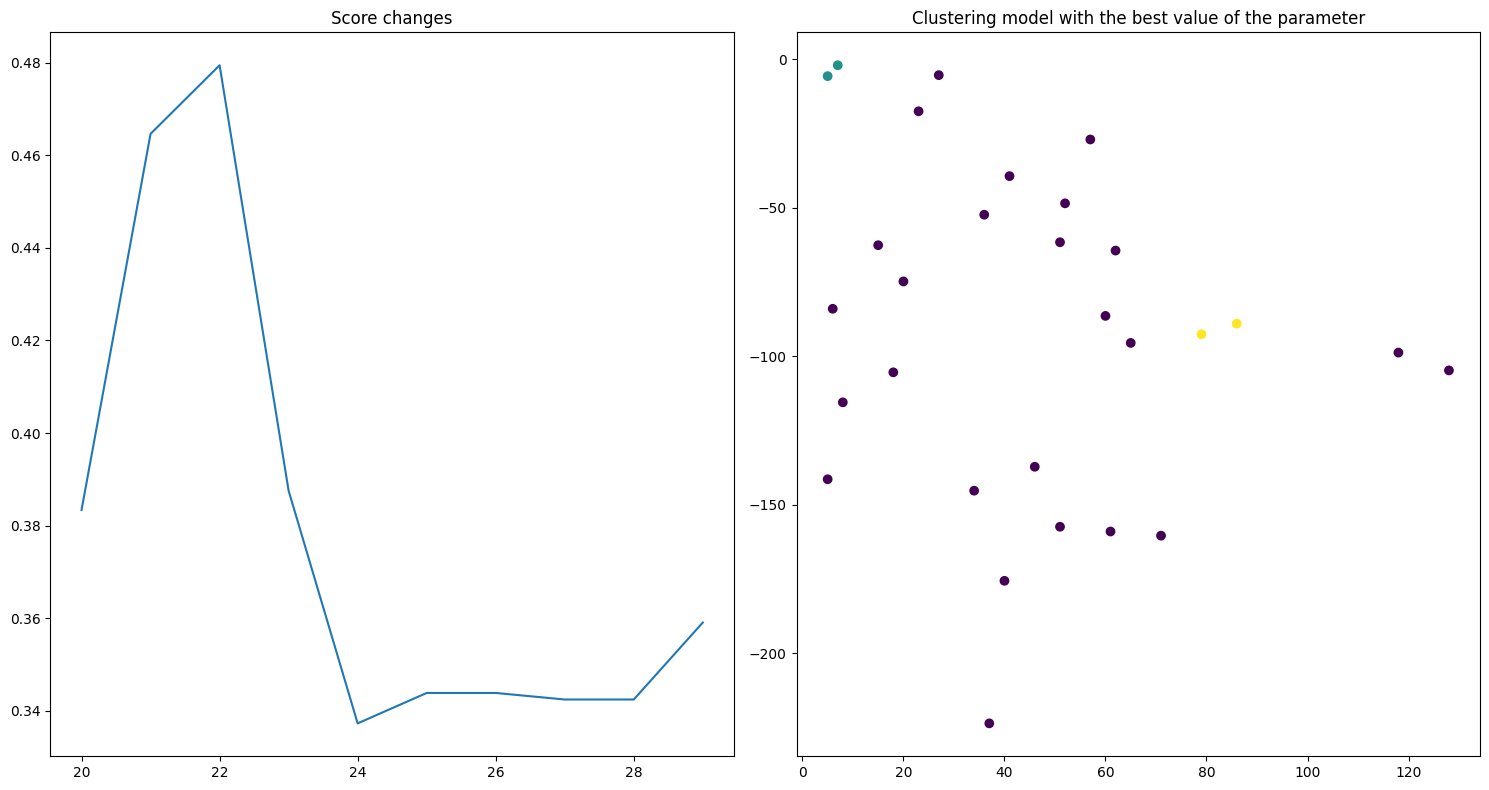

In [175]:
def func(type_of_model, features, param_name, param_range, **model_param):
    pairs = {}
    for num in param_range:
        param = {param_name: num}
        model = type_of_model(**model_param, **param)

        model.fit(features)
        labels = model.labels_

        silhoettte_avg = silhouette_score(features, labels)
        pairs[num] = silhoettte_avg 

    values = list(pairs.keys())
    scores = list(pairs.values())
    plt.figure(figsize=(15, 8))
    plt.subplot(1,2,1)
    plt.plot(values, scores)
    plt.title('Score changes')
    

    max_score = -1
    for num, score in enumerate(pairs):
        if score >= max_score:
            max_score = score
            best_num = int(num)

    best_param = {param_name: best_num}
    best_model = type_of_model(**model_param, **best_param)
    best_model.fit(features)
    labels = best_model.labels_

    plt.subplot(1,2,2)
    plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
    plt.title('Clustering model with the best value of the parameter')
    plt.tight_layout()
    plt.show()

func(type_of_model=DBSCAN, features=features, param_name="eps", param_range=range(20,30), min_samples=2)

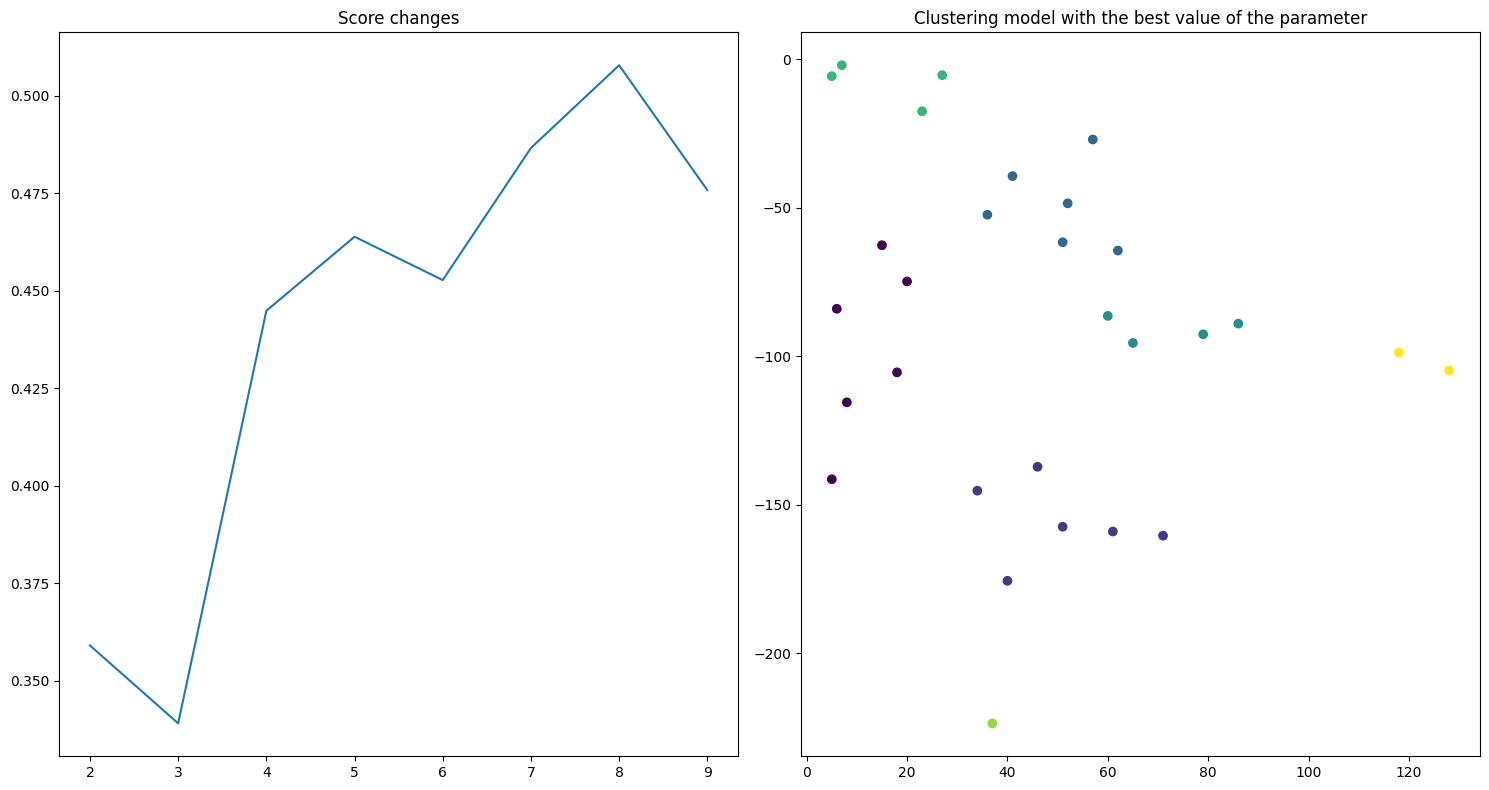

In [177]:
def func(type_of_model, features, param_name, param_range, **model_param):
    pairs = {}
    for num in param_range:
        param = {param_name: num}
        model = type_of_model(**model_param, **param)

        model.fit(features)
        labels = model.labels_

        silhoettte_avg = silhouette_score(features, labels)
        pairs[num] = silhoettte_avg 

    values = list(pairs.keys())
    scores = list(pairs.values())
    plt.figure(figsize=(15, 8))
    plt.subplot(1,2,1)
    plt.plot(values, scores)
    plt.title('Score changes')
    

    max_score = -1
    for num, score in enumerate(pairs):
        if score >= max_score:
            max_score = score
            best_num = int(num)

    best_param = {param_name: best_num}
    best_model = type_of_model(**model_param, **best_param)
    best_model.fit(features)
    labels = best_model.labels_

    plt.subplot(1,2,2)
    plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels)
    plt.title('Clustering model with the best value of the parameter')
    plt.tight_layout()
    plt.show()

func(type_of_model=AgglomerativeClustering, features=features, param_name="n_clusters", param_range=range(2, 10))